In [14]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns
import dabest
from struct import *
import osar
import scipy as sp
import re
import dabest

import warnings
from datetime import datetime
#import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope
date = datetime.today().strftime('%Y%m%d')

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

In [24]:
basegenotype = "SS81521"
responder = "Chrimson2"
wt = "w1118"
addNotes = basegenotype + " x " + responder
trans = addNotes

officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\"
specifiedpath = homecomp

baseDirectory_OSAR = specifiedpath + filedirectory_OSAR + addNotes


#OSAR related files
if len(addNotes) > 0:
    addNotes = "_" + addNotes   
filename_O = baseDirectory_OSAR + "\\" + basegenotype
filename_AppendDT = "_gen " + date
filename_O = filename_O + addNotes + filename_AppendDT

filename_O

'D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\SS81521 x Chrimson2\\SS81521_SS81521 x Chrimson2_gen 20260301'

In [25]:
def singleplottingdabest(dfi, names, parameter):
    plot_df = dfi[['status', parameter]].dropna(subset=[parameter]).copy()
    plot_df['status'] = plot_df['status'].replace({"Sibling": names + " Cntrl", "Offspring": names + " Test"})
    test = dabest.load(plot_df, idx=(names + " Cntrl", names + " Test"), x="status", y=parameter)
    return test

## Already have file

In [26]:
dir1 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
files2 = dir1 + trans + ".csv"
df=pd.read_csv(files2)

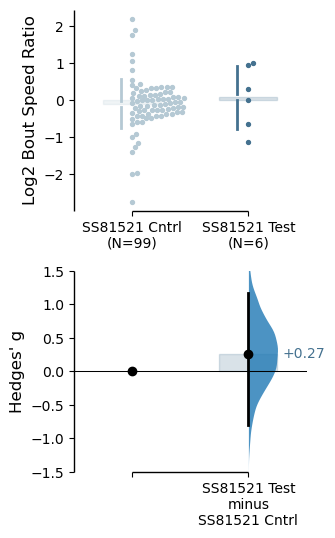

In [27]:
full_light = df[df["light_intensity"] == "Full"].reset_index(drop=True)
full_light['log2_pace_ratio_Pattern 01'] = full_light['log2_pace_ratio_Pattern 01'].replace([np.inf, -np.inf], np.nan)
singleplottingdabest(full_light, basegenotype,'log2_pace_ratio_Pattern 01').hedges_g.plot(float_contrast=False, fontsize_rawylabel=12, fontsize_rawxlabel=10, 
                                                                      fontsize_contrastxlabel=10, fontsize_contrastylabel=12, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", raw_label= "Log2 Bout Speed Ratio", contrast_ylim=(-1.5,1.5), contrast_label="Hedges' g");

## No compiled .csv file

In [7]:
# IF no current file already

osarAnalysis = osar.osar(baseDirectory_OSAR,
                        # border_shift_mm = 1.5,  
                        # countlog_folder = "countlog_Full Only",         
                        # countlog_folder = "countlog_Half and Full",
                         driver = basegenotype)

Creating borders for each fly...
Done.

Processing CSV 44 of 44
Summarising results for all flies...
All done.


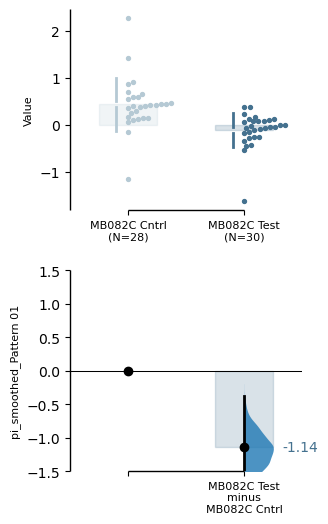

In [11]:
full_light = osarAnalysis.results[osarAnalysis.results['light_intensity'] == "Full"]
full_light['log2_pace_ratio_Pattern 01'] = full_light['log2_pace_ratio_Pattern 01'].replace([np.inf, -np.inf], np.nan)
singleplottingdabest(full_light, basegenotype,'log2_pace_ratio_Pattern 01').hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", contrast_label="pi_smoothed_Pattern 01", contrast_ylim=(-1.5,1.5));

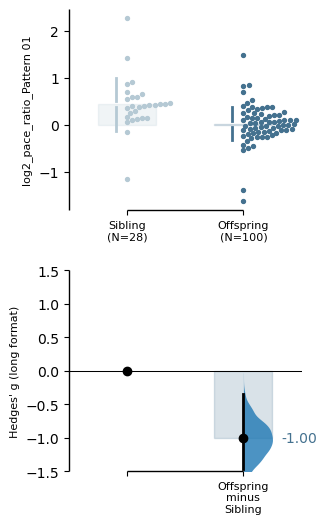

In [8]:
full_light2 = osarAnalysis.results[osarAnalysis.results['light_intensity'] == "Full"].copy()
full_light2['log2_pace_ratio_Pattern 01'] = full_light2['log2_pace_ratio_Pattern 01'].replace([np.inf, -np.inf], np.nan)
dabest.load(full_light2, idx=("Sibling", "Offspring"), x="status", y="log2_pace_ratio_Pattern 01").hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", contrast_label="Hedges' g (long format)", contrast_ylim=(-1.5,1.5));

In [9]:
full_light2.status.value_counts()

status
Offspring    112
Sibling       36
Name: count, dtype: int64

In [ ]:
full_light = osarAnalysis.results[osarAnalysis.results['light_intensity'] == "Full"]
singleplottingdabest(full_light, basegenotype,'pi_smoothed_Pattern 01').mean_diff.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", contrast_label="pi_smoothed_Pattern 01", contrast_ylim=(-1.5,1.5));